# Titanic Mini Exploratory Data Analysis (EDA)
In this notebook, we perform data cleaning and exploratory data analysis (EDA) to understand the factors affecting survival on the Titanic.

## 1. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

# Load the dataset
df = pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Data Cleaning
- Fill missing `Age` values with the mean age.
- Drop irrelevant columns like `Cabin` (too many missing values), `PassengerId`, `Name`, and `Ticket`.

In [2]:
# Fill missing Age with mean
mean_age = df['Age'].mean()
df['Age'] = df['Age'].fillna(mean_age)

# Drop irrelevant columns
columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df = df.drop(columns=columns_to_drop)

# Fill missing Embarked with the mode
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(mode_embarked)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


## 3. Feature Engineering
- Create a `FamilySize` column by adding `SibSp` (siblings/spouses) and `Parch` (parents/children).
- Create `AgeGroup` bins to categorize passengers by age.

In [3]:
# Create Family Size feature (including the passenger themselves)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Create Age Groups
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child (0-12)', 'Teen (13-18)', 'Young Adult (19-35)', 'Adult (36-60)', 'Senior (60+)']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

df[['Age', 'AgeGroup', 'SibSp', 'Parch', 'FamilySize']].head()

,Age,AgeGroup,SibSp,Parch,FamilySize
0,22.0,Young Adult (19-35),1,0,2
1,38.0,Adult (36-60),1,0,2
2,26.0,Young Adult (19-35),0,0,1
3,35.0,Adult (36-60),1,0,2
4,35.0,Adult (36-60),0,0,1


## 4. Analysis and Visualizations

### Q1: What is the age distribution?

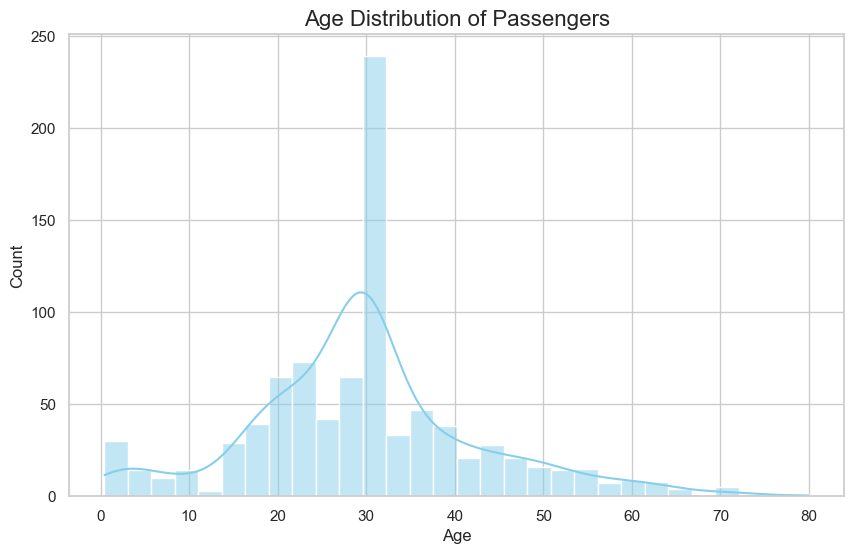

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=30, kde=True, color='skyblue')
plt.title('Age Distribution of Passengers', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

### Q2: Survival Rate by Age Group

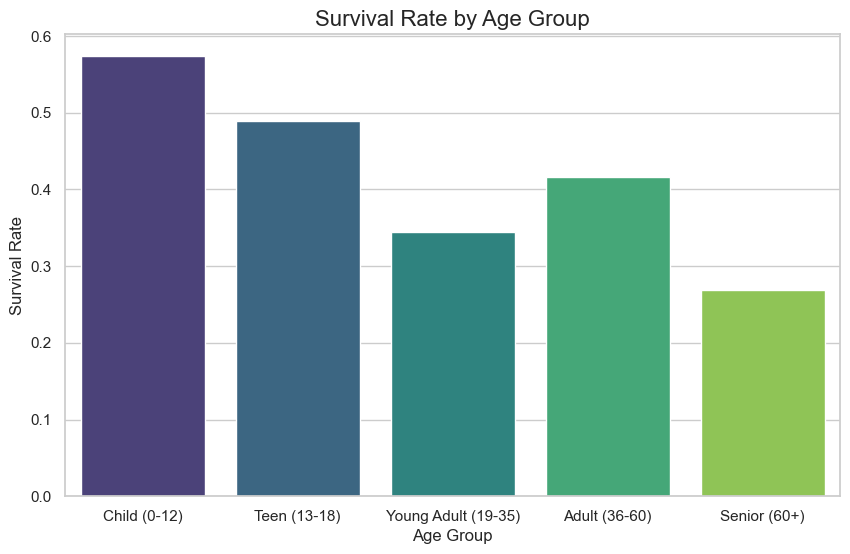

In [5]:
plt.figure(figsize=(10, 6))
sns.barplot(x='AgeGroup', y='Survived', data=df, errorbar=None, palette='viridis')
plt.title('Survival Rate by Age Group', fontsize=16)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.show()

### Q3: Survival Rate by Embarkation Port

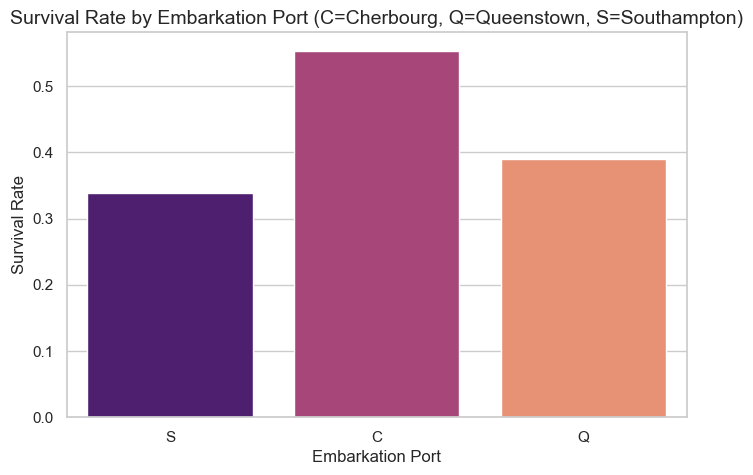

In [6]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Embarked', y='Survived', data=df, errorbar=None, palette='magma')
plt.title('Survival Rate by Embarkation Port (C=Cherbourg, Q=Queenstown, S=Southampton)', fontsize=14)
plt.xlabel('Embarkation Port', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.show()

### Q4: Survival by Family Size

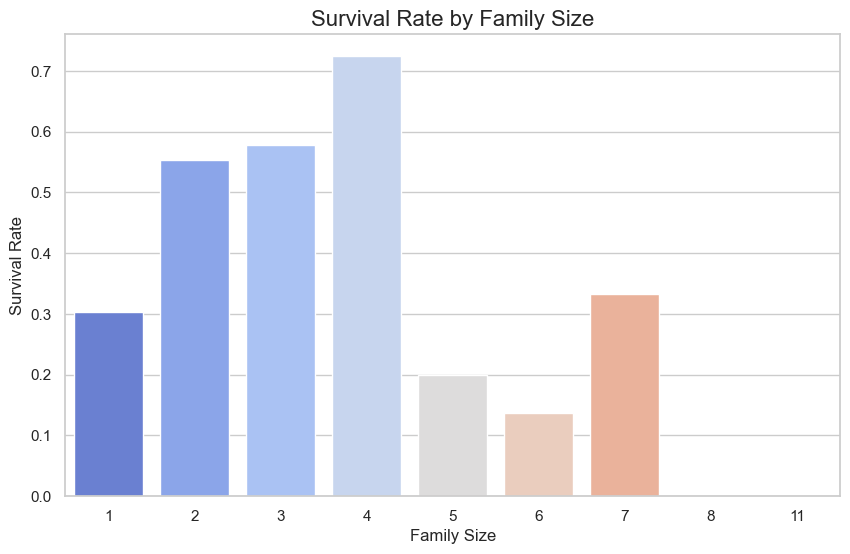

In [7]:
plt.figure(figsize=(10, 6))
sns.barplot(x='FamilySize', y='Survived', data=df, errorbar=None, palette='coolwarm')
plt.title('Survival Rate by Family Size', fontsize=16)
plt.xlabel('Family Size', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.show()

### Q5: Heatmap of Correlations

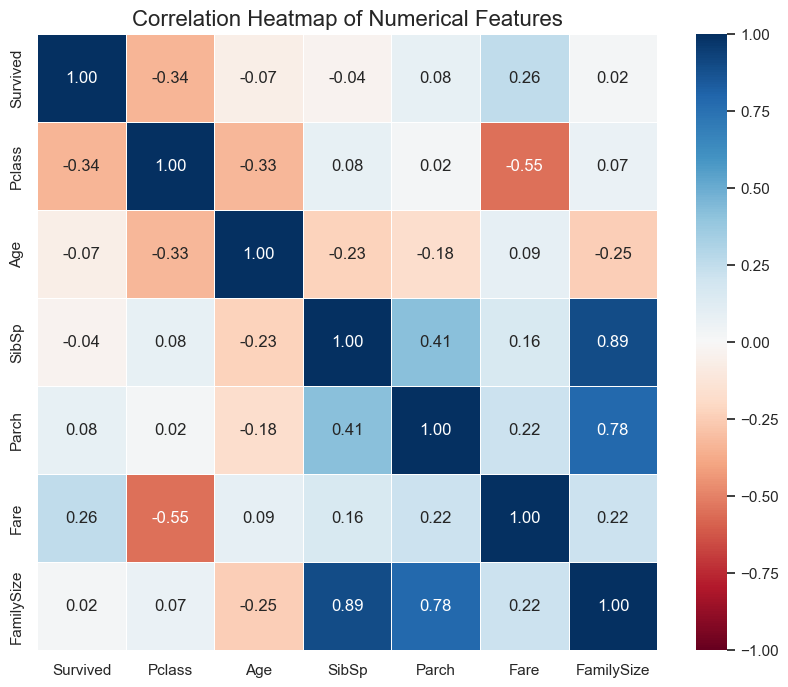

In [8]:
# Select only numerical columns for correlation heatmap
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt='.2f', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

## Conclusion
From the mini EDA above, we can draw the following insights:
1. **Age Distribution**: The majority of passengers were between 20 and 35 years old. (Missing values were imputed with the mean).
2. **Age Group & Survival**: Children (0-12) had the highest survival rate, supporting the 'women and children first' historical account.
3. **Embarkation Port & Survival**: Passengers who boarded at Cherbourg (C) had a higher survival rate compared to Southampton (S) and Queenstown (Q).
4. **Family Size & Survival**: Passengers traveling with a small family (2-4 members) had a much higher survival rate than those traveling alone or with large families (5+).
5. **Correlations**: There is a positive correlation between `Fare` and `Survived`, indicating passengers who paid more (likely 1st class) had a better chance of surviving. There's a negative correlation between `Pclass` and `Survived` (since 1st class is 1, and 3rd class is 3, lower class number = higher survival).